In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Diabetic_Retnopathy/efficientnet_b3_3class.keras"
)

print("Model loaded successfully")

Model loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
IMG_SIZE = 256
LAST_CONV_LAYER = "top_conv"   # EfficientNetB3 last conv layer

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 9bd008aab548.png to 9bd008aab548.png
Saving 122_left.png to 122_left.png


In [ ]:
img_path = list(uploaded.keys())[1]

img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

In [ ]:
preds = model.predict(img_array)

pred_class = np.argmax(preds[0])

class_names = ["No DR", "Non-Proliferative", "Vision-Threatening"]

print("Predicted Class:", class_names[pred_class])
print("Probabilities:", preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Class: No DR
Probabilities: [[0.89715034 0.09602705 0.00682256]]


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [ ]:
heatmap = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER)

# safety fix
heatmap = np.nan_to_num(heatmap)

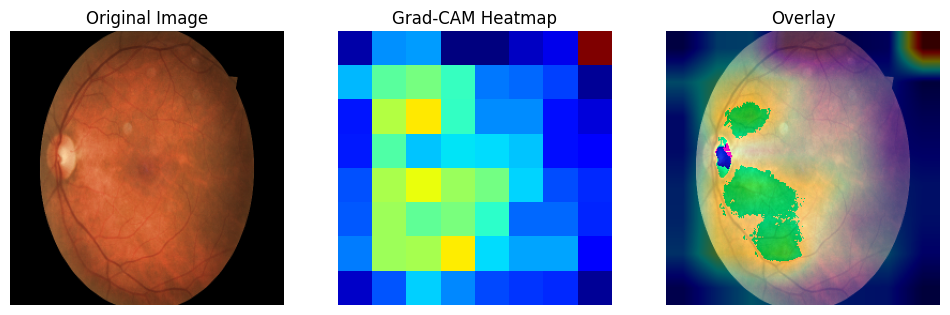

In [ ]:
img_original = cv2.imread(img_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_original = cv2.resize(img_original, (IMG_SIZE, IMG_SIZE))

heatmap_resized = cv2.resize(heatmap.astype('float32'), (IMG_SIZE, IMG_SIZE))
heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

overlay = 0.4 * heatmap_color + img_original
overlay = overlay.astype("uint8")

# -------- Display --------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

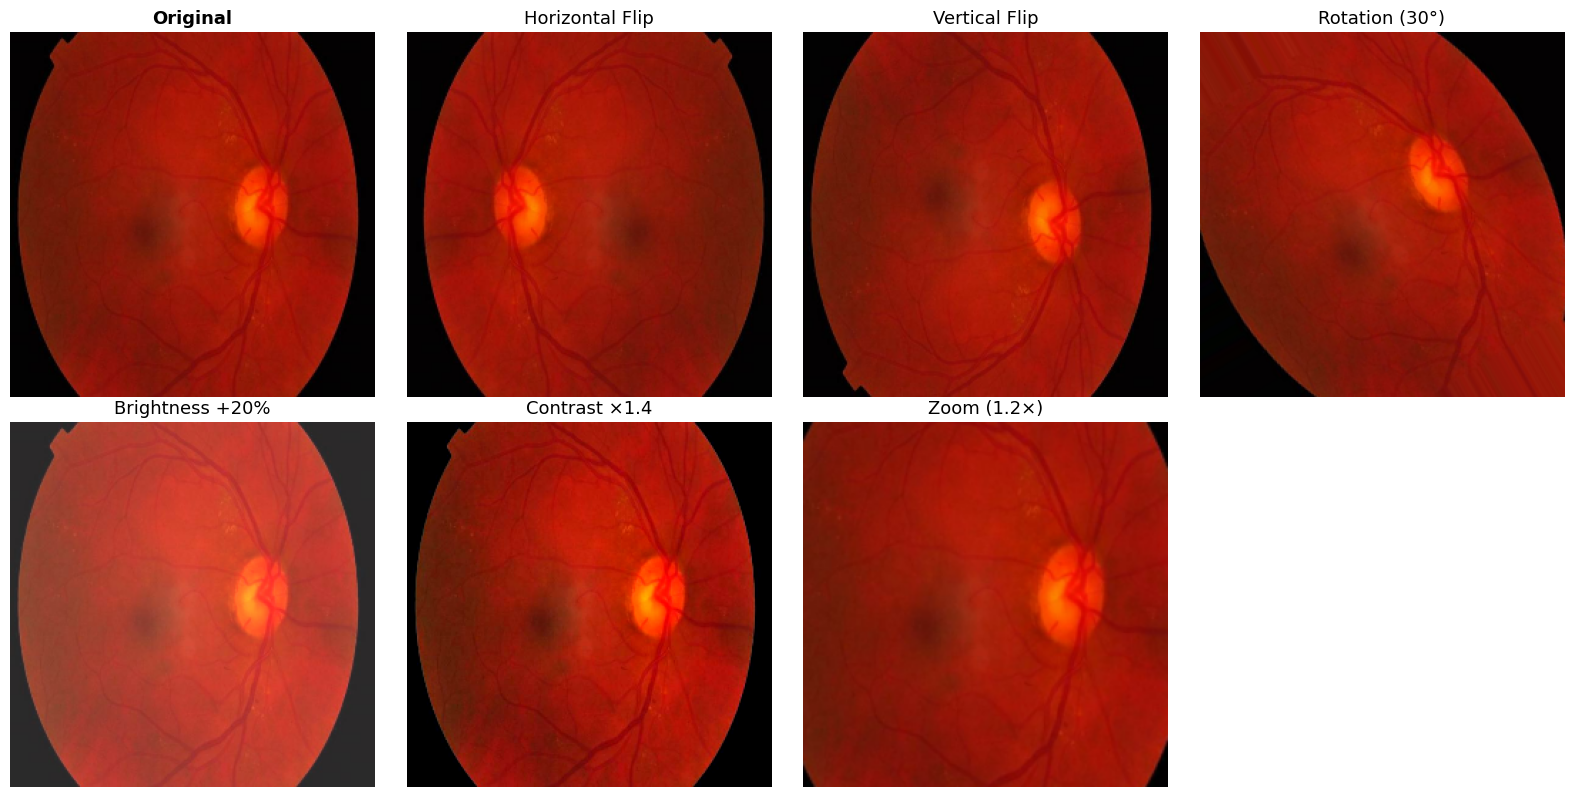

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
import scipy.ndimage

# ── Load a sample fundus image ─────────────────────────────────────────────
img_path = "/content/DR1.jpg"  # <-- UPDATE THIS
img = tf.io.read_file(img_path)
img = tf.image.decode_image(img, channels=3)
img = tf.image.resize(img, [256, 256])
img_np = img.numpy().astype(np.uint8)

# ── Define augmentation transforms ─────────────────────────────────────────
# All work on numpy uint8 arrays to avoid type issues

def horizontal_flip(image):
    return np.fliplr(image)

def vertical_flip(image):
    return np.flipud(image)

def rotation(image):
    return scipy.ndimage.rotate(image, angle=30, reshape=False, mode='nearest')

def brightness_jitter(image):
    return np.clip(image.astype(np.float32) + 40, 0, 255).astype(np.uint8)

def contrast_jitter(image):
    mean = image.mean(axis=(0, 1), keepdims=True)
    return np.clip((image.astype(np.float32) - mean) * 1.4 + mean, 0, 255).astype(np.uint8)

def zoom(image):
    h, w = image.shape[:2]
    crop = int(h * 0.1)  # 10% crop from each side = 1.2x zoom
    cropped = image[crop:h-crop, crop:w-crop]
    return np.array(tf.image.resize(cropped, [h, w])).astype(np.uint8)

# ── Apply transforms ───────────────────────────────────────────────────────
augmented = {
    "Original": img_np,
    "Horizontal Flip": horizontal_flip(img_np),
    "Vertical Flip": vertical_flip(img_np),
    "Rotation (30°)": rotation(img_np),
    "Brightness +20%": brightness_jitter(img_np),
    "Contrast ×1.4": contrast_jitter(img_np),
    "Zoom (1.2×)": zoom(img_np),
}

# ── Plot grid ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('white')

items = list(augmented.items())
for i, ax in enumerate(axes.flat):
    if i < len(items):
        title, image = items[i]
        ax.imshow(image)
        ax.set_title(title, fontsize=13, fontweight='bold' if i == 0 else 'normal')
    ax.axis('off')

axes[1, 3].axis('off')

plt.tight_layout(pad=1.0)
plt.savefig("augmentation_examples.png", dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
files.download("augmentation_examples.png")
